In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score


pd.set_option('display.max_columns', None)   # 모든 컬럼 표시
pd.set_option('display.width', None)         # 줄바꿈 없이 전체 폭 사용
pd.set_option('display.max_colwidth', None)  # 컬럼 내용 생략 안 함print(df)

df = pd.read_csv('data/reviews_joined_all_matched.csv')
df.head()

C:\Users\anajr\AppData\Local\Temp\ipykernel_7824\502487082.py:24: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/reviews_joined_all_matched.csv')


,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,developer_response,timestamp_dev_responded,primarily_steam_deck,appid_1,game_name,genre
0,2139460,199685023,76561198220582271,23,1,15240.0,0.0,15240,NaN,1.748034e+09,turkish,oyunu kurduk eyv oynadık vs zaten türk ü bırak oyuncu bulmak çok zor sadece rus kekolar var bol bol hadi bunları geçtik diyelim oynadık durduk bir güncelleme geldi neymiş yeni senaryo imiş tamam eyv süper güncelleme geliyor bi baktım 70 gb dedik oyun bayağı değişiyor gelişiyor neyse yaptık güncellemeyi baktım bi tek senaryo gelmiş değişen birşey yok tamam dedik eyv. geçen bir kere daha gireyim dedim yeni senaryo gelmiş bi baktım şimdi 64 gb lık bir güncelleme daha .Olum siz manyak mısınız zaten tek tük oyuncu var oynayan birde her senaryoda 70gb güncelleme mi olur mk. mal mısınız sildim sokarım oyununuza. Undawn a devam mk,1752389967,1752389967,False,17,2,0.712445,1,False,False,False,NaN,NaN,False,2139460,Once Human,"['Action', 'Adventure', 'RPG', 'Simulation', 'Strategy', 'Free To Play']"
1,2139460,199684668,76561198401253542,0,1,6249.0,0.0,834,NaN,1.755746e+09,spanish,me esta fasinando,1752389691,1752389691,True,0,0,0.500000,0,False,False,False,NaN,NaN,False,2139460,Once Human,"['Action', 'Adventure', 'RPG', 'Simulation', 'Strategy', 'Free To Play']"
2,2139460,199683985,76561199435851437,0,1,20522.0,0.0,12327,NaN,1.755124e+09,english,truly an amazing game,1752389204,1752389204,True,0,0,0.500000,0,False,False,False,NaN,NaN,False,2139460,Once Human,"['Action', 'Adventure', 'RPG', 'Simulation', 'Strategy', 'Free To Play']"
3,2139460,199683578,76561198977144059,83,30,22726.0,0.0,4090,NaN,1.755366e+09,english,amazing free to play .,1752388914,1752388914,True,0,0,0.500000,0,False,False,False,NaN,NaN,False,2139460,Once Human,"['Action', 'Adventure', 'RPG', 'Simulation', 'Strategy', 'Free To Play']"
4,2139460,199683575,76561199109403538,0,1,2747.0,0.0,2389,NaN,1.752985e+09,schinese,好,1752388911,1752388911,True,0,0,0.500000,0,False,False,False,NaN,NaN,False,2139460,Once Human,"['Action', 'Adventure', 'RPG', 'Simulation', 'Strategy', 'Free To Play']"


| 컬럼명(한글) | 컬럼명(영어) | 설명 | 분포(실제 분포) |
|---|---|---|---|
| 게임 ID | appid | Steam 게임 고유 ID | 440 ~ 3,241,660 (mean≈1,239,968) |
| 리뷰 추천 ID | recommendationid | 리뷰 고유 식별자 | 약 1.99e8 ~ 2.15e8 |
| 유저 Steam ID | steamid | 리뷰 작성자 Steam ID | 거의 단일값, 분산 매우 작음 |
| 보유 게임 수 | num_games_owned | 유저가 보유한 전체 게임 수 | 0 ~ 7,706 (median 0, mean 55.9) |
| 작성 리뷰 수 | num_reviews_author | 유저가 작성한 전체 리뷰 수 | 1 ~ 2,542 (median 3) |
| 누적 플레이 타임 | playtime_forever | 해당 게임 총 플레이 시간 | 5 ~ 1,457,369 |
| 최근 2주 플레이 타임 | playtime_last_two_weeks | 최근 2주간 플레이 시간 | 0 ~ 17,144 (75% ≤ 370) |
| 리뷰 시점 플레이 타임 | playtime_at_review | 리뷰 작성 시점 누적 플레이 시간 | 5 ~ 1,396,679 |
| Steam Deck 플레이 타임 | deck_playtime_at_review | 리뷰 시점 Steam Deck 플레이 시간 | 1 ~ 51,724 (표본 적음) |
| 마지막 플레이 시각 | last_played | 마지막 플레이 시점 (Unix) | 1.47e9 ~ 1.77e9 |
| 리뷰 생성 시각 | timestamp_created | 리뷰 최초 작성 시각 (Unix) | 1.75e9 ~ 1.77e9 |
| 리뷰 수정 시각 | timestamp_updated | 리뷰 최종 수정 시각 (Unix) | 생성 시각과 거의 동일 |
| 긍정 추천 여부 | voted_up | 긍정 리뷰 여부 (1=긍정) | mean 0.633 (긍정 약 63%) |
| 도움됨 투표 수 | votes_up | 도움이 됐다고 평가한 수 | 0 ~ 1,511 (대부분 0) |
| 재미있음 투표 수 | votes_funny | 재미있다고 평가한 수 | 0 ~ 438 (대부분 0) |
| 가중 투표 점수 | weighted_vote_score | Steam 내부 도움도 점수 | 0.29 ~ 0.95 (median 0.5) |
| 댓글 수 | comment_count | 리뷰에 달린 댓글 수 | 0 ~ 14 (99% 이상 0) |
| 개발자 응답 시각 | timestamp_dev_responded | 개발자 답변 시각 (Unix) | 존재 데이터 56건 |
| Steam 구매 여부 | steam_purchase | Steam에서 구매했는지 여부 | 없음 |
| 무료 획득 여부 | received_for_free | 무료로 받았는지 여부 | 없음 |
| 얼리액세스 작성 여부 | written_during_early_access | 얼리액세스 중 작성 여부 | 없음 |
| 리뷰 언어 | language | 리뷰 작성 언어 | 없음 |
| 리뷰 텍스트 | review | 리뷰 본문 텍스트 | 없음 |
| 개발자 응답 내용 | developer_response | 개발자 답변 텍스트 | 없음 |
| Steam Deck 주 사용 여부 | primarily_steam_deck | Steam Deck 위주 플레이 여부 | 없음 |
| 중복 appid | appid_1 | appid 중복 컬럼 | appid와 동일 |
| 난수 컬럼 | rnd | 무작위 샘플링용 컬럼 | 0 ~ 0.019 | 

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030656 entries, 0 to 1030655
Data columns (total 28 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   appid                        1030656 non-null  int64  
 1   recommendationid             1030656 non-null  int64  
 2   steamid                      1030656 non-null  int64  
 3   num_games_owned              1030656 non-null  int64  
 4   num_reviews_author           1030656 non-null  int64  
 5   playtime_forever             1030645 non-null  float64
 6   playtime_last_two_weeks      1030645 non-null  float64
 7   playtime_at_review           1030656 non-null  int64  
 8   deck_playtime_at_review      19544 non-null    float64
 9   last_played                  1030645 non-null  float64
 10  language                     1030656 non-null  object 
 11  review                       1027088 non-null  object 
 12  timestamp_created            1030656 non-n

In [97]:
df.isnull().sum()

appid                                0
recommendationid                     0
steamid                              0
num_games_owned                      0
num_reviews_author                   0
playtime_forever                    11
playtime_last_two_weeks             11
playtime_at_review                   0
deck_playtime_at_review        1011112
last_played                         11
language                             0
review                            3568
timestamp_created                    0
timestamp_updated                    0
voted_up                             0
votes_up                             0
votes_funny                          0
weighted_vote_score                  0
comment_count                        0
steam_purchase                       0
received_for_free                    0
written_during_early_access          0
developer_response             1027150
timestamp_dev_responded        1027150
primarily_steam_deck                 0
appid_1                  

In [98]:
df.describe()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,timestamp_created,timestamp_updated,votes_up,votes_funny,weighted_vote_score,comment_count,timestamp_dev_responded,appid_1
count,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030645e+06,1.030645e+06,1.030656e+06,19544.000000,1.030645e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,3.506000e+03,1.030656e+06
mean,1.246007e+06,2.078202e+08,7.656120e+16,5.589029e+01,9.407134e+00,1.421312e+04,4.750142e+02,1.179464e+04,1883.487055,1.762456e+09,1.760941e+09,1.761054e+09,6.485481e-01,1.244169e-01,5.027320e-01,4.645294e-02,1.759162e+09,1.246007e+06
std,8.606580e+05,4.897537e+06,6.086190e+08,1.973416e+02,6.927022e+01,3.357524e+04,1.155320e+03,3.145326e+04,5554.090679,1.173887e+07,4.747926e+06,4.725906e+06,1.345458e+01,3.082606e+00,2.275669e-02,6.260744e-01,4.410209e+06,8.606580e+05
min,4.400000e+02,1.994023e+08,7.656120e+16,0.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00,5.000000e+00,1.000000,1.345532e+09,1.752096e+09,1.752096e+09,0.000000e+00,0.000000e+00,1.352486e-01,0.000000e+00,1.752181e+09,4.400000e+02
25%,5.268700e+05,2.032641e+08,7.656120e+16,0.000000e+00,1.000000e+00,1.440000e+03,0.000000e+00,8.080000e+02,46.000000,1.761593e+09,1.756657e+09,1.756828e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.755116e+09,5.268700e+05
50%,1.172470e+06,2.081491e+08,7.656120e+16,0.000000e+00,3.000000e+00,4.408000e+03,0.000000e+00,2.723000e+03,276.000000,1.765687e+09,1.762017e+09,1.762260e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.759032e+09,1.172470e+06
75%,1.771300e+06,2.122663e+08,7.656120e+16,5.100000e+01,8.000000e+00,1.229500e+04,3.620000e+02,9.001000e+03,1462.000000,1.767210e+09,1.764576e+09,1.764617e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.763067e+09,1.771300e+06
max,3.241660e+06,2.152632e+08,7.656120e+16,3.370000e+04,1.974800e+04,2.457680e+06,3.460800e+04,2.416117e+06,157407.000000,1.767652e+09,1.767650e+09,1.767651e+09,5.763000e+03,1.425000e+03,9.897801e-01,2.580000e+02,1.767650e+09,3.241660e+06


In [99]:
df.columns

Index(['appid', 'recommendationid', 'steamid', 'num_games_owned',
       'num_reviews_author', 'playtime_forever', 'playtime_last_two_weeks',
       'playtime_at_review', 'deck_playtime_at_review', 'last_played',
       'language', 'review', 'timestamp_created', 'timestamp_updated',
       'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score',
       'comment_count', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'developer_response',
       'timestamp_dev_responded', 'primarily_steam_deck', 'appid_1',
       'game_name', 'genre'],
      dtype='object')

In [100]:
df.count()

appid                          1030656
recommendationid               1030656
steamid                        1030656
num_games_owned                1030656
num_reviews_author             1030656
playtime_forever               1030645
playtime_last_two_weeks        1030645
playtime_at_review             1030656
deck_playtime_at_review          19544
last_played                    1030645
language                       1030656
review                         1027088
timestamp_created              1030656
timestamp_updated              1030656
voted_up                       1030656
votes_up                       1030656
votes_funny                    1030656
weighted_vote_score            1030656
comment_count                  1030656
steam_purchase                 1030656
received_for_free              1030656
written_during_early_access    1030656
developer_response                3506
timestamp_dev_responded           3506
primarily_steam_deck           1030656
appid_1                  

In [ ]:

# 1. ROC-AUC 점수 확인을 위한 기본 전처리

df = df.copy()

df["review_dt"] = pd.to_datetime(df["timestamp_created"], unit="s", errors="coerce")
df = df.dropna(subset=["review_dt"]).copy()

# deck_playtime_at_review 결측 처리 (컬럼 있으면)
if "deck_playtime_at_review" in df.columns:
    df["deck_playtime_at_review"] = df["deck_playtime_at_review"].fillna(0)

# True/False -> 0/1 정리 (LightGBM 용)
bool_cols = [
    "primarily_steam_deck",
    "voted_up",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)


In [102]:

# 2. 180일 중 마지막 60일 제외

# 마지막 60일은 미래 정보에 해당하므로 라벨 생성에서 제외
# 과거 120일 구간만 사용해 학습용 라벨을 안정적으로 정의
END_DATE = df["review_dt"].max()
START_DATE = END_DATE - pd.Timedelta(days=180)
LABEL_CUTOFF = END_DATE - pd.Timedelta(days=60)

df_label = df[df["review_dt"] <= LABEL_CUTOFF].copy()

### 해당 프로젝트는 리뷰 시점을 기준으로 이탈을 예측하는 문제로 정의했습니다.
### 따라서 리뷰 이후의 행동만을 기준으로 타겟을 정의하여 예측 시점과 라벨 시점이 섞이는 데이터 누수를 방지했습니다.
### 데이터 수집 오류로 인해 리뷰 이전 시점의 last_played가 존재하는 경우는
### 정상적인 복귀로 해석할 수 없기 때문에 이탈로 보수적으로 처리했습니다.

In [103]:
# 3. churn 생성
df_label["last_played_dt"] = pd.to_datetime(df_label["last_played"], unit="s", errors="coerce")

# last_played가 Null이면 복귀 관측 안돼서 churn=1 처리
df_label["churn"] = (
    df_label["last_played_dt"].isna() | (df_label["last_played_dt"] <= (df_label["review_dt"] + pd.Timedelta(days=30)))
).astype(int)

In [104]:

# 4. 피처 선택 (도메인 기반 필터)
features = [
    "num_games_owned",
    "num_reviews_author",
    "deck_playtime_at_review",
    "voted_up",
    "votes_up",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "review_length"
]

# 존재하는 컬럼만 사용 (실행 에러 방지)
features = [c for c in features if c in df_label.columns]

# 숫자형 강제 (문자 섞이면 터짐)
for c in features:
    df_label[c] = pd.to_numeric(df_label[c], errors="coerce")

# 결측은 0으로 채움
X = df_label[features].fillna(0)
y = df_label["churn"].astype(int)


In [105]:
# 5. 시간 기준 Train/Valid Split (마지막 30일을 valid)
split_date = LABEL_CUTOFF - pd.Timedelta(days=30)

train_mask = df_label["review_dt"] <= split_date
valid_mask = df_label["review_dt"] > split_date

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]

print("Rows:", len(df_label), "| Train:", len(X_train), "| Valid:", len(X_valid))
print("Churn rate train:", round(y_train.mean(), 4), "| valid:", round(y_valid.mean(), 4))
print("Features used:", features)

# valid에 한 클래스만 있으면 AUC 계산이 안 됨
if y_valid.nunique() < 2:
    raise ValueError(f"Valid set에 클래스가 1개뿐입니다. (unique={y_valid.unique()}) split_date를 조정하거나 기간을 늘려야 합니다.")


Rows: 535135 | Train: 414585 | Valid: 120550
Churn rate train: 0.3508 | valid: 0.4337
Features used: ['num_games_owned', 'num_reviews_author', 'deck_playtime_at_review', 'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'review_length']


In [106]:
# 6. LightGBM 학습 + ROC-AUC
model = LGBMClassifier(
    objective="binary",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

pred = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, pred)
print(f"Validation ROC-AUC: {auc:.4f}")

[LightGBM] [Info] Number of positive: 145442, number of negative: 269143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1511
[LightGBM] [Info] Number of data points in the train set: 414585, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350813 -> initscore=-0.615465
[LightGBM] [Info] Start training from score -0.615465
Validation ROC-AUC: 0.6262


## AUC-ROC 점수가 유의미한 점수라고 판단 해당 데이터셋 선택 최종 확정

## EDA

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030656 entries, 0 to 1030655
Data columns (total 30 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   appid                        1030656 non-null  int64         
 1   recommendationid             1030656 non-null  int64         
 2   steamid                      1030656 non-null  int64         
 3   num_games_owned              1030656 non-null  int64         
 4   num_reviews_author           1030656 non-null  int64         
 5   playtime_forever             1030645 non-null  float64       
 6   playtime_last_two_weeks      1030645 non-null  float64       
 7   playtime_at_review           1030656 non-null  int64         
 8   deck_playtime_at_review      1030656 non-null  float64       
 9   last_played                  1030645 non-null  float64       
 10  language                     1030656 non-null  object        
 11  review     

In [108]:
df.isnull().sum()

appid                                0
recommendationid                     0
steamid                              0
num_games_owned                      0
num_reviews_author                   0
playtime_forever                    11
playtime_last_two_weeks             11
playtime_at_review                   0
deck_playtime_at_review              0
last_played                         11
language                             0
review                            3568
timestamp_created                    0
timestamp_updated                    0
voted_up                             0
votes_up                             0
votes_funny                          0
weighted_vote_score                  0
comment_count                        0
steam_purchase                       0
received_for_free                    0
written_during_early_access          0
developer_response             1027150
timestamp_dev_responded        1027150
primarily_steam_deck                 0
appid_1                  

In [109]:
# 결측치 제거
df.drop(columns=['developer_response','timestamp_dev_responded'],inplace=True)
df = df.dropna(subset=['review','playtime_last_two_weeks','playtime_forever','last_played'])
df.isnull().sum()

appid                          0
recommendationid               0
steamid                        0
num_games_owned                0
num_reviews_author             0
playtime_forever               0
playtime_last_two_weeks        0
playtime_at_review             0
deck_playtime_at_review        0
last_played                    0
language                       0
review                         0
timestamp_created              0
timestamp_updated              0
voted_up                       0
votes_up                       0
votes_funny                    0
weighted_vote_score            0
comment_count                  0
steam_purchase                 0
received_for_free              0
written_during_early_access    0
primarily_steam_deck           0
appid_1                        0
game_name                      0
genre                          0
review_dt                      0
review_length                  0
dtype: int64

In [110]:
# 이상치
df.describe()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid_1,review_dt,review_length
count,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1027077,1.027077e+06
mean,1.246218e+06,2.078205e+08,7.656120e+16,5.591921e+01,9.398358e+00,1.422662e+04,4.750545e+02,1.180767e+04,3.580167e+01,1.762453e+09,1.760942e+09,1.761054e+09,8.621593e-01,6.506211e-01,1.248115e-01,5.027439e-01,4.661189e-02,6.124458e-01,4.189267e-02,1.116206e-01,6.249775e-03,1.246218e+06,2025-10-20 06:27:25.201984768,1.106045e+02
min,4.400000e+02,1.994023e+08,7.656120e+16,0.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,1.345532e+09,1.752096e+09,1.752096e+09,0.000000e+00,0.000000e+00,0.000000e+00,1.352486e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.400000e+02,2025-07-09 21:24:44,1.000000e+00
25%,5.268700e+05,2.032650e+08,7.656120e+16,0.000000e+00,1.000000e+00,1.440000e+03,0.000000e+00,8.080000e+02,0.000000e+00,1.761592e+09,1.756658e+09,1.756830e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.268700e+05,2025-08-31 16:26:33,7.000000e+00
50%,1.172470e+06,2.081504e+08,7.656120e+16,0.000000e+00,3.000000e+00,4.411000e+03,0.000000e+00,2.727000e+03,0.000000e+00,1.765687e+09,1.762018e+09,1.762262e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.172470e+06,2025-11-01 17:21:57,2.200000e+01
75%,1.771300e+06,2.122644e+08,7.656120e+16,5.100000e+01,8.000000e+00,1.230900e+04,3.620000e+02,9.012000e+03,0.000000e+00,1.767210e+09,1.764574e+09,1.764615e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.771300e+06,2025-12-01 07:33:13,7.400000e+01
max,3.241660e+06,2.152632e+08,7.656120e+16,3.370000e+04,1.974800e+04,2.457680e+06,3.460800e+04,2.416117e+06,1.574070e+05,1.767652e+09,1.767650e+09,1.767651e+09,1.000000e+00,5.763000e+03,1.425000e+03,9.897801e-01,2.580000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.241660e+06,2026-01-05 22:01:13,8.000000e+03
std,8.609537e+05,4.896923e+06,6.085837e+08,1.974617e+02,6.935847e+01,3.360347e+04,1.155415e+03,3.148088e+04,8.081001e+02,1.175115e+07,4.747388e+06,4.725320e+06,3.447329e-01,1.347795e+01,3.087957e+00,2.278943e-02,6.271562e-01,4.871921e-01,2.003440e-01,3.148993e-01,7.880813e-02,8.609537e+05,NaN,3.533517e+02


In [ ]:
# 플레 시간 관련 컬럼들이 말도 안되는 초헤비 유저 > 봇사용 의심 + 영향력 
# 1) 상위 99.9% 캡 
cap = df["playtime_forever"].quantile(0.999)

# 2) 캡 + log1p 처리해서 바로 덮어쓰기
df["playtime_forever"] = np.log1p(
    df["playtime_forever"].clip(upper=cap)
)

# 플레이 시간은 누수가 있어서 피쳐로는 사용 안하지만 플레이시간을 제거함으로써 다른 시간 이상치를 같이 처리 해주었다

In [115]:
# num_games_owned
# median: 0
# 75%: 51
# max: 33,700
# std: 197
cap = df["num_games_owned"].quantile(0.999)
df["num_games_owned"] = np.log1p(df["num_games_owned"].clip(upper=cap))

In [116]:
# num_reviews_author
# median: 3
# 75%: 8
# max: 19,748
cap = df["num_reviews_author"].quantile(0.999)
df["num_reviews_author"] = np.log1p(df["num_reviews_author"].clip(upper=cap))

In [117]:
df.describe()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid_1,review_dt,review_length,is_ending_genre
count,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1.027077e+06,1027077,1.027077e+06,1.027077e+06
mean,1.246218e+06,2.078205e+08,7.656120e+16,1.862805e+00,1.662801e+00,8.350030e+00,4.750545e+02,1.180767e+04,3.580167e+01,1.762453e+09,1.760942e+09,1.761054e+09,8.621593e-01,6.506211e-01,1.248115e-01,5.027439e-01,4.661189e-02,6.124458e-01,4.189267e-02,1.116206e-01,6.249775e-03,1.246218e+06,2025-10-20 06:27:25.201984768,1.106045e+02,5.111963e-01
min,4.400000e+02,1.994023e+08,7.656120e+16,0.000000e+00,6.931472e-01,1.791759e+00,0.000000e+00,5.000000e+00,0.000000e+00,1.345532e+09,1.752096e+09,1.752096e+09,0.000000e+00,0.000000e+00,0.000000e+00,1.352486e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.400000e+02,2025-07-09 21:24:44,1.000000e+00,0.000000e+00
25%,5.268700e+05,2.032650e+08,7.656120e+16,0.000000e+00,6.931472e-01,7.273093e+00,0.000000e+00,8.080000e+02,0.000000e+00,1.761592e+09,1.756658e+09,1.756830e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.268700e+05,2025-08-31 16:26:33,7.000000e+00,0.000000e+00
50%,1.172470e+06,2.081504e+08,7.656120e+16,0.000000e+00,1.386294e+00,8.392083e+00,0.000000e+00,2.727000e+03,0.000000e+00,1.765687e+09,1.762018e+09,1.762262e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.172470e+06,2025-11-01 17:21:57,2.200000e+01,1.000000e+00
75%,1.771300e+06,2.122644e+08,7.656120e+16,3.951244e+00,2.197225e+00,9.418167e+00,3.620000e+02,9.012000e+03,0.000000e+00,1.767210e+09,1.764574e+09,1.764615e+09,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.771300e+06,2025-12-01 07:33:13,7.400000e+01,1.000000e+00
max,3.241660e+06,2.152632e+08,7.656120e+16,7.674582e+00,5.676754e+00,1.285269e+01,3.460800e+04,2.416117e+06,1.574070e+05,1.767652e+09,1.767650e+09,1.767651e+09,1.000000e+00,5.763000e+03,1.425000e+03,9.897801e-01,2.580000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.241660e+06,2026-01-05 22:01:13,8.000000e+03,1.000000e+00
std,8.609537e+05,4.896923e+06,6.085837e+08,2.180613e+00,9.557001e-01,1.630759e+00,1.155415e+03,3.148088e+04,8.081001e+02,1.175115e+07,4.747388e+06,4.725320e+06,3.447329e-01,1.347795e+01,3.087957e+00,2.278943e-02,6.271562e-01,4.871921e-01,2.003440e-01,3.148993e-01,7.880813e-02,8.609537e+05,NaN,3.533517e+02,4.998749e-01


<Axes: >

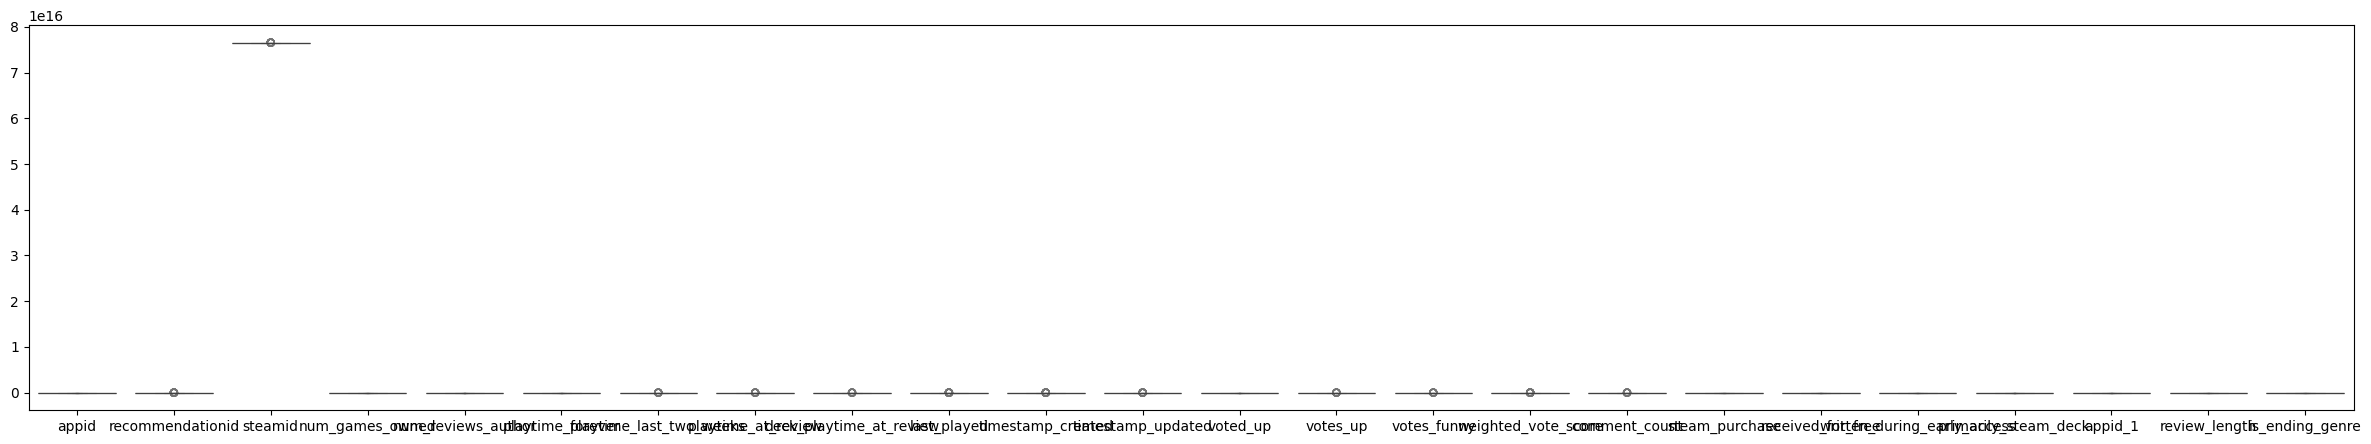

In [119]:
plt.figure(figsize=(30,5))

sns.boxenplot(df)

In [114]:
# 장르에 따른 분류
ending_genre = [
  "Visual Novel",
  "Interactive Fiction",
  "Walking Simulator",
  "Story Rich",
  "Adventure",
  "Puzzle",
  "Horror",
  "Mystery",
  "Psychological Horror",
  "Narrative"
]

df["is_ending_genre"] = df["genre"].apply(
    lambda g: int(any(x in g for x in ending_genre))
)

In [ ]:
# 텍스트

In [ ]:
# 4. 피처 선택 (도메인 기반 필터)
features = [
    "num_games_owned",
    "num_reviews_author",
    "deck_playtime_at_review",
    "voted_up",
    "votes_up",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "review_length"
]

# 존재하는 컬럼만 사용 (실행 에러 방지)
features = [c for c in features if c in df_label.columns]

# 숫자형 강제 (문자 섞이면 터짐)
for c in features:
    df_label[c] = pd.to_numeric(df_label[c], errors="coerce")

# 결측은 0으로 채움
X = df_label[features].fillna(0)
y = df_label["churn"].astype(int)

In [ ]:
# 5. 시간 기준 Train/Valid Split (마지막 30일을 valid)
split_date = LABEL_CUTOFF - pd.Timedelta(days=30)

train_mask = df_label["review_dt"] <= split_date
valid_mask = df_label["review_dt"] > split_date

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]

print("Rows:", len(df_label), "| Train:", len(X_train), "| Valid:", len(X_valid))
print("Churn rate train:", round(y_train.mean(), 4), "| valid:", round(y_valid.mean(), 4))
print("Features used:", features)

# valid에 한 클래스만 있으면 AUC 계산이 안 됨
if y_valid.nunique() < 2:
    raise ValueError(f"Valid set에 클래스가 1개뿐입니다. (unique={y_valid.unique()}) split_date를 조정하거나 기간을 늘려야 합니다.")


In [ ]:
# 6. LightGBM 학습 + ROC-AUC
model = LGBMClassifier(
    objective="binary",
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc"
)

pred = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, pred)
print(f"Validation ROC-AUC: {auc:.4f}")